<a href="https://colab.research.google.com/github/book150243/Homework_DADS6003/blob/main/DADS6003_6810422005_Nanthiwat_Tawilpri.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import warnings
import numpy as np
warnings.filterwarnings('ignore')
from sklearn.preprocessing import MultiLabelBinarizer
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
train_set = "https://raw.githubusercontent.com/book150243/Homework_DADS6003/refs/heads/main/train.csv"
test_set = "https://raw.githubusercontent.com/book150243/Homework_DADS6003/refs/heads/main/test.csv"
train_df = pd.read_csv(train_set)


RANDOM_STATE = 42
TEST_SIZE = 0.3
CV_FOLDS = 5
OPTUNA_N_TRIALS = 50

np.random.seed(RANDOM_STATE)

### Clean Data set

In [3]:
print("Dataset Statistics:")
print(train_df.info())

print("\nMissing Values:")
print(train_df.isnull().sum().sum())

Dataset Statistics:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        80000 non-null  object 
 1   Customer_ID               80000 non-null  object 
 2   Month                     80000 non-null  object 
 3   Name                      71992 non-null  object 
 4   Age                       80000 non-null  object 
 5   SSN                       80000 non-null  object 
 6   Occupation                80000 non-null  object 
 7   Annual_Income             80000 non-null  object 
 8   Monthly_Inhand_Salary     68038 non-null  float64
 9   Num_Bank_Accounts         80000 non-null  int64  
 10  Num_Credit_Card           80000 non-null  int64  
 11  Interest_Rate             80000 non-null  int64  
 12  Num_of_Loan               80000 non-null  object 
 13  Type_of_Loan              70787 non-null 

In [4]:
display(train_df.head(5))

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1d1af,CUS_0x3539,February,an Arakalid,30,995-31-4669,Manager,43391.96,3688.996667,1,...,Good,1468.28,29.112468,23 Years and 8 Months,No,0.000000,53.969385063055675,High_spent_Large_value_payments,554.9302816036111,Good
1,0x1ebd6,CUS_0x8716,January,Matthewz,18,185-99-8068,Scientist,14351.21,NaN,8,...,Bad,4766.87,39.849732,NaN,Yes,61.098718,118.08021357217683,Low_spent_Small_value_payments,238.3144849566528,Poor
2,0x8a66,CUS_0x21dc,January,Tom Miless,41,241-53-8475,Developer,130125.04,10871.753333,5,...,Good,1195.05,21.542892,15 Years and 11 Months,No,204.285650,1255.8993022448951,Low_spent_Small_value_payments,NaN,Good
3,0x1d769,CUS_0x32d3,April,Lisaa,35,204-78-6176,Manager,20107.21,1631.600833,6,...,Standard,2544.6,32.423759,19 Years and 4 Months,Yes,27.106395,66.81977464950728,Low_spent_Small_value_payments,359.23391378882377,Poor
4,0x236dd,CUS_0xadad,August,Masond,27,027-11-6852,Doctor,92186.19,7487.182500,1,...,Good,809.01,39.543131,20 Years and 9 Months,No,185.797654,115.52003931707223,High_spent_Medium_value_payments,697.4005568630175,Good


In [5]:
train_df.dtypes

,0
ID,object
Customer_ID,object
Month,object
Name,object
Age,object
SSN,object
Occupation,object
Annual_Income,object
Monthly_Inhand_Salary,float64
Num_Bank_Accounts,int64


### Cleaning Outliers in 'Num_Credit_Inquiries' by Customer_ID

In [6]:
cols_to_fix_str = ['Annual_Income', 'Num_of_Delayed_Payment', 'Outstanding_Debt','Num_of_Loan']

for col in cols_to_fix_str:
    train_df[col] = train_df[col].str.replace('_', '').astype(float)

train_df['Changed_Credit_Limit'] = train_df['Changed_Credit_Limit'].replace('_', np.nan)

train_df['Changed_Credit_Limit'] = pd.to_numeric(train_df['Changed_Credit_Limit'], errors='coerce')

train_df['Credit_Mix'] = train_df['Credit_Mix'].replace('_', np.nan)
train_df["Age"] = train_df["Age"].str.replace('_','').astype(int)
train_df["Age"] = train_df["Age"].where(train_df["Age"].between(1, 120), other=np.nan)
train_df["Payment_Behaviour"]      = train_df["Payment_Behaviour"].replace("!@9#%8", np.nan)

cols_to_fix_nan = ['Amount_invested_monthly', 'Monthly_Balance']
for col in cols_to_fix_nan:
    train_df[col] = pd.to_numeric(train_df[col], errors='coerce')

def split_convert(age_str):
    if pd.isna(age_str):
        return None
    parts = str(age_str).split()

    try:
        return (int(parts[0]) * 12) + int(parts[3])
    except:
        return None

train_df['Credit_History_Age_Months'] = train_df['Credit_History_Age'].apply(split_convert)

train_df['Occupation'] = train_df['Occupation'].replace('_______', np.nan)

train_df['Occupation'] = train_df.groupby('Customer_ID')['Occupation'].ffill().bfill()

In [7]:
train_df.dtypes

,0
ID,object
Customer_ID,object
Month,object
Name,object
Age,float64
SSN,object
Occupation,object
Annual_Income,float64
Monthly_Inhand_Salary,float64
Num_Bank_Accounts,int64


In [8]:
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
train_df['Month'] = pd.Categorical(train_df['Month'], categories=month_order, ordered=True)

train_df['month_num'] = train_df['Month'].cat.codes

train_df['credit_history_base'] = train_df['Credit_History_Age_Months'] - train_df['month_num']

numeric_cols_for_customer_imputation = train_df[['Age', 'Monthly_Inhand_Salary', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries','Amount_invested_monthly', 'Monthly_Balance','credit_history_base']].columns.tolist()
numeric_cols_for_customer_imputation_str = train_df[['Payment_Behaviour','Payment_of_Min_Amount','Credit_Mix','Type_of_Loan','Occupation']].columns.tolist()

train_customer_id_imputation_medians = train_df.groupby('Customer_ID')[numeric_cols_for_customer_imputation].median()

train_customer_id_imputation_mode = train_df.groupby('Customer_ID')[numeric_cols_for_customer_imputation_str].agg(lambda x: x.mode()[0] if not x.mode().empty else np.nan)

print("Customer_ID-specific imputation medians learned from training data:")
display(train_customer_id_imputation_medians.head())
print("\nCustomer_ID-specific imputation modes learned from training data:")
display(train_customer_id_imputation_mode.head())

Customer_ID-specific imputation medians learned from training data:


,Age,Monthly_Inhand_Salary,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Amount_invested_monthly,Monthly_Balance,credit_history_base
Customer_ID,,,,,,,,
CUS_0x1000,17.0,2706.161667,25.0,1.63,11.0,183.983667,308.691409,122.0
CUS_0x1009,26.0,4250.390000,18.0,9.73,4.0,150.795934,424.207803,365.0
CUS_0x100b,18.5,9549.782500,7.0,11.34,2.5,520.541236,886.771375,183.0
CUS_0x1011,44.0,5208.872500,15.0,14.42,7.0,251.601966,294.101467,183.0
CUS_0x1013,44.0,7962.415000,9.0,1.33,3.0,323.428128,524.795288,207.0



Customer_ID-specific imputation modes learned from training data:


,Payment_Behaviour,Payment_of_Min_Amount,Credit_Mix,Type_of_Loan,Occupation
Customer_ID,,,,,
CUS_0x1000,High_spent_Small_value_payments,Yes,Bad,"Credit-Builder Loan, and Home Equity Loan",Lawyer
CUS_0x1009,High_spent_Medium_value_payments,Yes,Standard,"Not Specified, Home Equity Loan, Credit-Builde...",Mechanic
CUS_0x100b,High_spent_Large_value_payments,No,Good,NaN,Media_Manager
CUS_0x1011,Low_spent_Medium_value_payments,Yes,Standard,"Student Loan, Credit-Builder Loan, and Debt Co...",Doctor
CUS_0x1013,High_spent_Medium_value_payments,No,Good,"Student Loan, Debt Consolidation Loan, and Per...",Mechanic


In [9]:
#train_df['Num_of_Loan'] = train_df['Num_of_Loan'].replace(-100.0, np.nan)
train_df['Payment_of_Min_Amount'] = train_df['Payment_of_Min_Amount'].replace('NM', np.nan)
train_df.loc[train_df['Num_of_Delayed_Payment'] < 0, 'Num_of_Delayed_Payment'] = np.nan
train_df.loc[train_df['Delay_from_due_date'] < 0, 'Delay_from_due_date'] = 0
train_df.loc[train_df['Num_Bank_Accounts'] < 0, 'Num_Bank_Accounts'] = 0

def fill_with_customer_median(row, col):
    cid = row['Customer_ID']  # ถ้า Customer_ID อยู่ใน index ให้ปรับ
    if cid in train_customer_id_imputation_medians.index:
        return train_customer_id_imputation_medians.loc[cid, col]
    return np.nan  # fallback ถ้า Customer_ID ไม่มีใน train

for col in numeric_cols_for_customer_imputation:
    mask = train_df[col].isna()
    train_df.loc[mask, col] = train_df[mask].apply(
        lambda row: fill_with_customer_median(row, col), axis=1
    )

def fill_with_customer_mode(row, col):
    cid = row['Customer_ID']  # ถ้า Customer_ID อยู่ใน index ให้ปรับ
    if cid in train_customer_id_imputation_mode.index:
        return train_customer_id_imputation_mode.loc[cid, col]
    return np.nan

for col in numeric_cols_for_customer_imputation_str:
    mask = train_df[col].isna()
    train_df.loc[mask, col] = train_df[mask].apply(
        lambda row: fill_with_customer_mode(row, col), axis=1
    )


train_df['Credit_History_Age_Months'] = train_df['credit_history_base'] + train_df['month_num']
train_df = train_df.drop(columns=['month_num', 'credit_history_base'])

train_df['Num_of_Delayed_Payment'] = train_df['Num_of_Delayed_Payment'].transform(lambda x: x.fillna(x.median()))
train_df['Credit_History_Age_Months'] = train_df['Credit_History_Age_Months'].transform(lambda x: x.fillna(x.median()))

train_df = train_df.reset_index(drop=True)


train_df['Type_of_Loan'] = train_df['Type_of_Loan'].fillna('No_loan')

train_df['Type_of_Loan'] = train_df['Type_of_Loan'].str.replace('and ', '', regex=False).str.split(',').apply(lambda x: [item.strip() for item in x])

train_df['Num_of_Loan'] = train_df['Type_of_Loan'].apply(lambda x: len([loan for loan in x if loan.strip() != 'No_loan']))

mlb = MultiLabelBinarizer()
one_hot_encoded = mlb.fit_transform(train_df['Type_of_Loan'])

one_hot_df = pd.DataFrame(one_hot_encoded, columns=mlb.classes_)

train_df = pd.concat([train_df, one_hot_df], axis=1)

train_df['Payment_Behaviour'] = train_df['Payment_Behaviour'].fillna('Unknown')

In [10]:
def replace_outliers_with_mode(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Calculate mode, handling cases where it might return multiple modes or be empty
    mode_val = series[(series >= lower_bound) & (series <= upper_bound)].mode()
    if not mode_val.empty:
        mode_val = mode_val[0]
    else:
        # Fallback if no non-outlier mode exists, e.g., use the overall mode or median of the group
        mode_val = series.mode()[0] if not series.mode().empty else series.median()

    # Replace outliers with the calculated mode
    series = series.mask((series < lower_bound) | (series > upper_bound), mode_val)
    return series

# Apply the function grouped by Customer_ID
train_df['Num_Credit_Inquiries'] = train_df.groupby('Customer_ID')['Num_Credit_Inquiries'].transform(replace_outliers_with_mode)

score_map = {
    'Poor': 0,
    'Standard': 1,
    'Good': 2
}

# ใช้ .map() เพื่อแปลงค่า
train_df['Credit_Score'] = train_df['Credit_Score'].map(score_map)



# Extreme Outlier Mitigation (Winsorization at 1% and 99%)
skewed_cols = ['Annual_Income', 'Monthly_Inhand_Salary', 'Outstanding_Debt', 'Amount_invested_monthly', 'Total_EMI_per_month', 'Monthly_Balance', 'Delay_from_due_date', 'Age', 'Credit_History_Age_Months']
winsor_bounds = {}
for col in skewed_cols:
    if col in train_df.columns:
        lower = train_df[col].quantile(0.01)
        upper = train_df[col].quantile(0.99)
        winsor_bounds[col] = (lower, upper)
        train_df[col] = train_df[col].clip(lower, upper)

# Fill NaN strings for dummies
train_df['Credit_Mix'] = train_df['Credit_Mix'].fillna(train_df['Credit_Mix'].mode()[0])

In [11]:

# Advanced Feature Engineering (Train)
train_df['Debt_to_Income_Ratio'] = (train_df['Outstanding_Debt'] / (train_df['Monthly_Inhand_Salary'].fillna(1000).replace(0, 1000))).fillna(0)
train_df['EMI_to_Income_Ratio'] = (train_df['Total_EMI_per_month'] / (train_df['Monthly_Inhand_Salary'].fillna(1000).replace(0, 1000))).fillna(0)
train_df['Invested_to_Income_Ratio'] = (train_df['Amount_invested_monthly'] / (train_df['Monthly_Inhand_Salary'].fillna(1000).replace(0, 1000))).fillna(0)
train_df['Delayed_per_Loan_Ratio'] = (train_df['Num_of_Delayed_Payment'] / (train_df['Num_of_Loan'].fillna(0) + 1)).fillna(0)

# Binning logic
train_df['Age_under_25'] = (train_df['Age'] < 25).astype(int)
train_df['Age_25_to_40'] = ((train_df['Age'] >= 25) & (train_df['Age'] <= 40)).astype(int)
train_df['Age_over_40'] = (train_df['Age'] > 40).astype(int)

train_df['Credit_History_Short'] = (train_df['Credit_History_Age_Months'] < 120).astype(int)
train_df['Credit_History_Medium'] = ((train_df['Credit_History_Age_Months'] >= 120) & (train_df['Credit_History_Age_Months'] <= 240)).astype(int)
train_df['Credit_History_Long'] = (train_df['Credit_History_Age_Months'] > 240).astype(int)


columns_to_onehot = ['Occupation', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']

# Apply one-hot encoding
train_df = pd.get_dummies(train_df, columns=columns_to_onehot, drop_first=False)

print("One-hot encoding applied successfully.")
display(train_df.head())

One-hot encoding applied successfully.


,ID,Customer_ID,Month,Name,Age,SSN,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,...,Credit_Mix_Standard,Payment_of_Min_Amount_NM,Payment_of_Min_Amount_No,Payment_of_Min_Amount_Yes,Payment_Behaviour_High_spent_Large_value_payments,Payment_Behaviour_High_spent_Medium_value_payments,Payment_Behaviour_High_spent_Small_value_payments,Payment_Behaviour_Low_spent_Large_value_payments,Payment_Behaviour_Low_spent_Medium_value_payments,Payment_Behaviour_Low_spent_Small_value_payments
0,0x1d1af,CUS_0x3539,February,an Arakalid,30.0,995-31-4669,43391.96,3688.996667,1,5,...,False,False,True,False,True,False,False,False,False,False
1,0x1ebd6,CUS_0x8716,January,Matthewz,18.0,185-99-8068,14351.21,1274.934167,8,7,...,False,False,False,True,False,False,False,False,False,True
2,0x8a66,CUS_0x21dc,January,Tom Miless,41.0,241-53-8475,130125.04,10871.753333,5,2,...,False,False,True,False,False,False,False,False,False,True
3,0x1d769,CUS_0x32d3,April,Lisaa,35.0,204-78-6176,20107.21,1631.600833,6,6,...,True,False,False,True,False,False,False,False,False,True
4,0x236dd,CUS_0xadad,August,Masond,27.0,027-11-6852,92186.19,7487.182500,1,2,...,False,False,True,False,False,True,False,False,False,False


In [12]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 72 columns):
 #   Column                                              Non-Null Count  Dtype   
---  ------                                              --------------  -----   
 0   ID                                                  80000 non-null  object  
 1   Customer_ID                                         80000 non-null  object  
 2   Month                                               80000 non-null  category
 3   Name                                                71992 non-null  object  
 4   Age                                                 80000 non-null  float64 
 5   SSN                                                 80000 non-null  object  
 6   Annual_Income                                       80000 non-null  float64 
 7   Monthly_Inhand_Salary                               80000 non-null  float64 
 8   Num_Bank_Accounts                                   80000 non-null

In [13]:
train_df[train_df['Customer_ID']=='CUS_0x563d'][['Customer_ID', 'Credit_History_Age_Months','Credit_Mix_Bad','Credit_Score']]

,Customer_ID,Credit_History_Age_Months,Credit_Mix_Bad,Credit_Score
6523,CUS_0x563d,220.0,False,0


In [14]:
train_df[train_df['Credit_History_Age_Months'].isna()]

,ID,Customer_ID,Month,Name,Age,SSN,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,...,Credit_Mix_Standard,Payment_of_Min_Amount_NM,Payment_of_Min_Amount_No,Payment_of_Min_Amount_Yes,Payment_Behaviour_High_spent_Large_value_payments,Payment_Behaviour_High_spent_Medium_value_payments,Payment_Behaviour_High_spent_Small_value_payments,Payment_Behaviour_Low_spent_Large_value_payments,Payment_Behaviour_Low_spent_Medium_value_payments,Payment_Behaviour_Low_spent_Small_value_payments


In [15]:
train_df.dtypes

,0
ID,object
Customer_ID,object
Month,category
Name,object
Age,float64
...,...
Payment_Behaviour_High_spent_Medium_value_payments,bool
Payment_Behaviour_High_spent_Small_value_payments,bool
Payment_Behaviour_Low_spent_Large_value_payments,bool
Payment_Behaviour_Low_spent_Medium_value_payments,bool


In [16]:
train_df.isna().sum()[train_df.isna().sum() > 0]

,0
Name,8008
Credit_History_Age,7223


In [17]:
train_df_final = train_df.drop(columns=['ID','Month', 'Name', 'SSN','Type_of_Loan','Credit_History_Age'])

In [18]:
train_df_final.dtypes[train_df.dtypes == 'object']

,0
Customer_ID,object


In [19]:
train_df_final[['Age','Num_of_Delayed_Payment']] = train_df_final[['Age','Num_of_Delayed_Payment']].astype(int)
train_df_final

,Customer_ID,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,...,Credit_Mix_Standard,Payment_of_Min_Amount_NM,Payment_of_Min_Amount_No,Payment_of_Min_Amount_Yes,Payment_Behaviour_High_spent_Large_value_payments,Payment_Behaviour_High_spent_Medium_value_payments,Payment_Behaviour_High_spent_Small_value_payments,Payment_Behaviour_Low_spent_Large_value_payments,Payment_Behaviour_Low_spent_Medium_value_payments,Payment_Behaviour_Low_spent_Small_value_payments
0,CUS_0x3539,30,43391.960,3688.996667,1,5,10,0,9,6,...,False,False,True,False,True,False,False,False,False,False
1,CUS_0x8716,18,14351.210,1274.934167,8,7,18,6,18,17,...,False,False,False,True,False,False,False,False,False,True
2,CUS_0x21dc,41,130125.040,10871.753333,5,2,11,2,3,0,...,False,False,True,False,False,False,False,False,False,True
3,CUS_0x32d3,35,20107.210,1631.600833,6,6,32,2,15,13,...,True,False,False,True,False,False,False,False,False,True
4,CUS_0xadad,27,92186.190,7487.182500,1,2,12,4,1,0,...,False,False,True,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79995,CUS_0x74d5,25,661365.730,2010.150000,5,6,9,2,30,9,...,False,False,True,False,True,False,False,False,False,False
79996,CUS_0xbf40,27,81864.560,6882.046667,8,5,11,2,6,16,...,True,False,False,True,False,False,True,False,False,False
79997,CUS_0x5300,20,7985.155,870.429583,6,10,31,7,50,16,...,False,False,False,True,False,False,False,False,True,False
79998,CUS_0x6a84,45,69279.380,5836.281667,3,5,8,0,6,10,...,False,False,True,False,False,False,False,True,False,False


In [20]:
corr_matrix = train_df_final.drop(columns=['Customer_ID']).corr()
train_df_final_all = train_df_final.drop(columns=['Customer_ID'])
train_df_final_target = train_df_final_all['Credit_Score']
train_df_final_data = train_df_final_all.drop(columns=['Credit_Score'])

In [21]:
train_df_final_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 64 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   Age                                                 80000 non-null  int64  
 1   Annual_Income                                       80000 non-null  float64
 2   Monthly_Inhand_Salary                               80000 non-null  float64
 3   Num_Bank_Accounts                                   80000 non-null  int64  
 4   Num_Credit_Card                                     80000 non-null  int64  
 5   Interest_Rate                                       80000 non-null  int64  
 6   Num_of_Loan                                         80000 non-null  int64  
 7   Delay_from_due_date                                 80000 non-null  int64  
 8   Num_of_Delayed_Payment                              80000 non-null  int64  


### correlation select

Payment_of_Min_Amount_No     0.443635
Payment_of_Min_Amount_Yes    0.439252
Credit_Mix_Good              0.433556
Delay_from_due_date          0.432807
Credit_Mix_Bad               0.392976
Credit_History_Age_Months    0.388105
Outstanding_Debt             0.386675
Credit_History_Long          0.366733
Num_of_Loan                  0.357580
Debt_to_Income_Ratio         0.292889
Credit_History_Short         0.255309
Monthly_Balance              0.214021
Monthly_Inhand_Salary        0.212666
Changed_Credit_Limit         0.168037
Credit_History_Medium        0.164139
Age                          0.160968
No_loan                      0.159016
Amount_invested_monthly      0.154610
Auto Loan                    0.151384
Payday Loan                  0.142665
Name: Credit_Score, dtype: float64


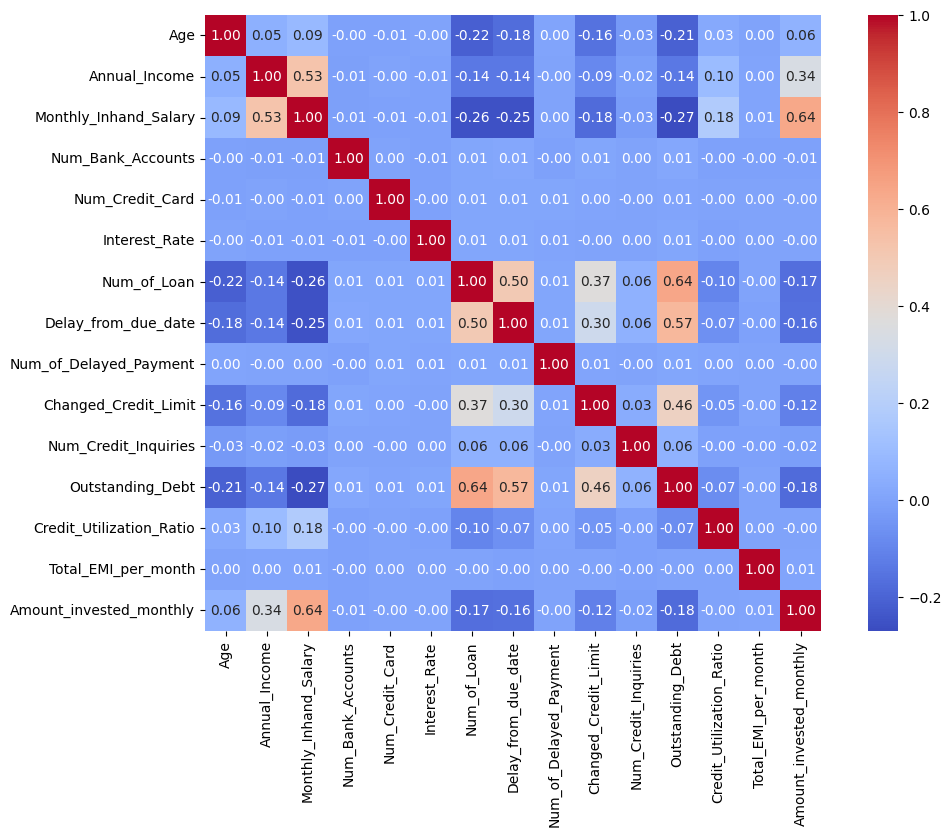

In [22]:
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix.iloc[:15,:15], annot=True, fmt=".2f", cmap="coolwarm", square=True)

corr_with_target = corr_matrix['Credit_Score'].drop('Credit_Score').abs().sort_values(ascending=False)[:20]
print(corr_with_target)

In [23]:
corr_threshold = 0.2
corr_with_target = corr_matrix['Credit_Score'].drop('Credit_Score').abs().sort_values(ascending=False)
selected_features_corr = corr_with_target[corr_with_target > corr_threshold].index.tolist()
print(f"\nSelected features (correlation > {corr_threshold}): {len(selected_features_corr)}")
print(selected_features_corr)


Selected features (correlation > 0.2): 13
['Payment_of_Min_Amount_No', 'Payment_of_Min_Amount_Yes', 'Credit_Mix_Good', 'Delay_from_due_date', 'Credit_Mix_Bad', 'Credit_History_Age_Months', 'Outstanding_Debt', 'Credit_History_Long', 'Num_of_Loan', 'Debt_to_Income_Ratio', 'Credit_History_Short', 'Monthly_Balance', 'Monthly_Inhand_Salary']


### select Kbest

In [24]:
from sklearn.feature_selection import SelectKBest, f_classif

k_features = 10
selector_kbest = SelectKBest(score_func=f_classif, k=k_features)
X_kbest = selector_kbest.fit_transform(train_df_final_data, train_df_final_target)

selected_mask = selector_kbest.get_support()
selected_features_kbest = [f for f, selected in zip(train_df_final_data.columns, selected_mask) if selected]

print(f"Top {k_features} features selected by SelectKBest (f_classif):")
print(selected_features_kbest)

print("\nF-scores for all features (top 10):")
for feature, score in sorted(zip(train_df_final_data.columns, selector_kbest.scores_),
                              key=lambda x: x[1], reverse=True)[:10]:
    print(f"  {feature}: {score:.4f}")

Top 10 features selected by SelectKBest (f_classif):
['Num_of_Loan', 'Delay_from_due_date', 'Outstanding_Debt', 'Credit_History_Age_Months', 'Credit_History_Long', 'Credit_Mix_Bad', 'Credit_Mix_Good', 'Credit_Mix_Standard', 'Payment_of_Min_Amount_No', 'Payment_of_Min_Amount_Yes']

F-scores for all features (top 10):
  Credit_Mix_Good: 16362.3746
  Payment_of_Min_Amount_No: 11503.2362
  Payment_of_Min_Amount_Yes: 11253.9171
  Delay_from_due_date: 9240.8080
  Credit_Mix_Bad: 7829.2668
  Outstanding_Debt: 7277.2881
  Credit_History_Age_Months: 7093.5399
  Credit_Mix_Standard: 6890.9476
  Credit_History_Long: 6217.6444
  Num_of_Loan: 5914.4329


### L1

In [25]:
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

lr_fs = LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced', random_state=RANDOM_STATE, max_iter=1000, C = 0.001)
lr_fs.fit(train_df_final_data, train_df_final_target)

selector_lr = SelectFromModel(lr_fs, prefit=True)
X_lr_selected = selector_lr.transform(train_df_final_data)

selected_mask_lr = selector_lr.get_support()
selected_features_lr = [f for f, selected in zip(train_df_final_data, selected_mask_lr) if selected]

print("Features selected by Logistic Regression L1 (non-zero coefficients):")
print(selected_features_lr)
print(f"\nNumber of features selected: {len(selected_features_lr)}")

Features selected by Logistic Regression L1 (non-zero coefficients):
['Age', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Amount_invested_monthly', 'Monthly_Balance', 'Credit_History_Age_Months', 'Delayed_per_Loan_Ratio', 'Credit_History_Medium', 'Credit_Mix_Good', 'Credit_Mix_Standard']

Number of features selected: 19


### Feature selection

In [26]:
fs_comparison = pd.DataFrame({'Feature': list(train_df_final_data.columns)})
fs_comparison['Correlation'] = fs_comparison['Feature'].isin(selected_features_corr)
fs_comparison['SelectKBest'] = fs_comparison['Feature'].isin(selected_features_kbest)
fs_comparison['L1_Logistic'] = fs_comparison['Feature'].isin(selected_features_lr)

fs_comparison.set_index('Feature', inplace=True)
print("Feature Selection Comparison:")
print(fs_comparison)

print("\nNumber of features selected by each method:")
print(f"  Correlation-based: {len(selected_features_corr)}")
print(f"  SelectKBest (k={k_features}): {len(selected_features_kbest)}")
print(f"  L1 Logistic: {len(selected_features_lr)}")

best_features = fs_comparison[fs_comparison.sum(axis=1) >= 2] #Majority vote
print(best_features)

Feature Selection Comparison:
                                                    Correlation  SelectKBest  \
Feature                                                                        
Age                                                       False        False   
Annual_Income                                             False        False   
Monthly_Inhand_Salary                                      True        False   
Num_Bank_Accounts                                         False        False   
Num_Credit_Card                                           False        False   
...                                                         ...          ...   
Payment_Behaviour_High_spent_Medium_value_payments        False        False   
Payment_Behaviour_High_spent_Small_value_payments         False        False   
Payment_Behaviour_Low_spent_Large_value_payments          False        False   
Payment_Behaviour_Low_spent_Medium_value_payments         False        False   
Payment_Be

## Data Preprocessing & Train-Test Split

### Holdout technique

In [27]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

#best_indices = [feature_names_list.index(f) for f in best_features]
X_best = train_df_final_data[best_features.index.to_list()]

# Define the groups based on Customer_ID
groups = train_df_final['Customer_ID']

# Initialize GroupShuffleSplit
gss = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)

# Get the train and test indices
for train_idx, test_idx in gss.split(X_best, train_df_final_target, groups):
    X_train, X_test = X_best.iloc[train_idx], X_best.iloc[test_idx]
    y_train, y_test = train_df_final_target.iloc[train_idx], train_df_final_target.iloc[test_idx]


print(f"\nShape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")
print(f"\nClass distribution in y_train: {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"Class distribution in y_test: {dict(zip(*np.unique(y_test, return_counts=True)))}")


Shape of X_train: (55914, 12)
Shape of X_test: (24086, 12)
Shape of y_train: (55914,)
Shape of y_test: (24086,)

Class distribution in y_train: {np.int64(0): np.int64(16146), np.int64(1): np.int64(29788), np.int64(2): np.int64(9980)}
Class distribution in y_test: {np.int64(0): np.int64(6995), np.int64(1): np.int64(12749), np.int64(2): np.int64(4342)}


## Pipeline , hyper parameter tuning

In [28]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import matthews_corrcoef, roc_auc_score, accuracy_score, f1_score

In [29]:
from scipy.stats import loguniform
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import StratifiedKFold

# Use the pipeline
pipelines = {
    'LogisticRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', LogisticRegression(max_iter=2000))
    ]),
    'GaussianNB': Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', GaussianNB())
    ])
}

# Parameter grids for each classifier
param_grids = {
    'LogisticRegression': {
        'classifier__C': [0.01, 0.1, 1, 10, 100],
        'classifier__penalty': ['l1', 'l2'],
        'classifier__solver': ['liblinear', 'saga'],
        'classifier__class_weight': [None, 'balanced']
    },
    'GaussianNB': {
        'classifier__var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]
    }
}


# Parameter distributions for each classifier
param_distributions = {
    'LogisticRegression': {
        'classifier__C': loguniform(0.01, 100),
        'classifier__penalty': ['l1', 'l2'],
        'classifier__solver': ['liblinear', 'saga'],
        'classifier__class_weight': [None, 'balanced']
    },
    'GaussianNB': {
        'classifier__var_smoothing': loguniform(1e-9, 1e-5)
    }
}

results = {}

for name, pipeline in pipelines.items():
    print(f"\n{'='*60}")
    print(f"Training {name} with RandomizedSearchCV")
    print('='*60)

    random_search = RandomizedSearchCV(pipeline, param_distributions[name], n_iter=10,
                                       scoring='f1_macro', cv=StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE),
                                       n_jobs=-1, random_state=RANDOM_STATE)
    random_search.fit(X_train, y_train)

    print(f"Best parameters found by RandomizedSearchCV for {name}:")
    print(random_search.best_params_)

    best_random_model = random_search.best_estimator_
    y_pred_random = best_random_model.predict(X_test)

    acc_random = accuracy_score(y_test, y_pred_random)
    f1_random = f1_score(y_test, y_pred_random, average='macro')
    mcc_random = matthews_corrcoef(y_test, y_pred_random)

    results[name] = {'accuracy': acc_random, 'f1': f1_random, 'mcc': mcc_random}

# Summary comparison
print("\n" + "="*60)
print("SUMMARY: Model Comparison (RandomizedSearchCV)")
print('='*60)
for name, metrics in results.items():
    print(f"{name}: Accuracy = {metrics['accuracy']:.4f}, F1 = {metrics['f1']:.4f}, MCC = {metrics['mcc']:.4f}")


Training LogisticRegression with RandomizedSearchCV
Best parameters found by RandomizedSearchCV for LogisticRegression:
{'classifier__C': np.float64(0.012087541473056965), 'classifier__class_weight': 'balanced', 'classifier__penalty': 'l2', 'classifier__solver': 'saga'}

Training GaussianNB with RandomizedSearchCV
Best parameters found by RandomizedSearchCV for GaussianNB:
{'classifier__var_smoothing': np.float64(3.148911647956859e-08)}

SUMMARY: Model Comparison (RandomizedSearchCV)
LogisticRegression: Accuracy = 0.6383, F1 = 0.6325, MCC = 0.4519
GaussianNB: Accuracy = 0.6315, F1 = 0.6280, MCC = 0.4567


### Optuna

In [30]:
!pip install optuna -qqq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 7.5 MB/s eta 0:00:00


In [31]:
import optuna
from optuna.samplers import TPESampler
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, RobustScaler, PowerTransformer, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import roc_auc_score, matthews_corrcoef, average_precision_score

# Define stratified CV for reproducibility
cv_splitter = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
def objective(trial):
    classifier_name = trial.suggest_categorical("classifier", ["LogisticRegression", "GaussianNB"])

    scaler_name = trial.suggest_categorical("scaler", ["StandardScaler", "RobustScaler", "PowerTransformer"])
    if scaler_name == "StandardScaler":
        scaler = StandardScaler()
    elif scaler_name == "RobustScaler":
        scaler = RobustScaler()
    else:
        scaler = PowerTransformer()

    pipe = Pipeline([
        ('scaler', scaler),
        ('classifier', None)
    ])

    if classifier_name == "LogisticRegression":
        C = trial.suggest_float("lr_C", 1e-4, 1000, log=True)
        penalty = trial.suggest_categorical("lr_penalty", ["l1", "l2"])
        solver = trial.suggest_categorical("lr_solver", ['liblinear', 'saga'])
        pipe.set_params(classifier=LogisticRegression(
            C=C,
            penalty=penalty,
            solver=solver,
            random_state=RANDOM_STATE,
            max_iter=2000,
            class_weight='balanced'))

    elif classifier_name == "GaussianNB":
        var_smoothing = trial.suggest_float("nb_var_smoothing", 1e-11, 1e-3, log=True)
        pipe.set_params(classifier=GaussianNB(var_smoothing=var_smoothing))

    score = cross_val_score(pipe, X_train, y_train, cv=cv_splitter,
                          scoring='f1_macro', n_jobs=-1)

    return score.mean()

In [32]:
#Set seed properly with TPESampler
study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=RANDOM_STATE))

study.optimize(objective, n_trials=OPTUNA_N_TRIALS)

if study.best_trial is not None:

    print("Best parameters found by Optuna:")
    print(study.best_params)

    print(f"Best value: {study.best_value:.4f}")

    best_params = study.best_params
    best_classifier_name = best_params["classifier"]


    best_scaler_name = best_params.get("scaler", "StandardScaler")
    if best_scaler_name == "StandardScaler":
        best_scaler = StandardScaler()
    elif best_scaler_name == "RobustScaler":
        best_scaler = RobustScaler()
    else:
        best_scaler = PowerTransformer()

    best_pipeline = Pipeline([
        ('scaler', best_scaler),
        ('classifier', None)
    ])


    if best_classifier_name == "LogisticRegression":
        best_C = best_params["lr_C"]
        best_penalty = best_params["lr_penalty"]
        best_solver = best_params["lr_solver"]
        best_pipeline.set_params(classifier=LogisticRegression(
            C=best_C, penalty=best_penalty, solver=best_solver,
            random_state=RANDOM_STATE, max_iter=1000,
            class_weight='balanced'))
    elif best_classifier_name == "GaussianNB":
        best_var_smoothing = best_params["nb_var_smoothing"]
        best_pipeline.set_params(classifier=GaussianNB(
            var_smoothing=best_var_smoothing))

    best_pipeline.fit(X_train, y_train)
    y_pred_optuna = best_pipeline.predict(X_test)
    y_proba_optuna = best_pipeline.predict_proba(X_test) # Get probabilities for ROC AUC

    roc_auc_optuna = roc_auc_score(y_test, y_proba_optuna, multi_class='ovr', average='weighted')
    mcc_optuna = matthews_corrcoef(y_test, y_pred_optuna)
    f1_optuna = f1_score(y_test, y_pred_optuna, average='macro')

    print(f"\nTest ROC-AUC: {roc_auc_optuna:.4f}")
    print(f"Test MCC: {mcc_optuna:.4f}")
    print(f"Test F1: {f1_optuna:.4f}")
else:
    print("Optuna did not complete any trials successfully.")

print("\n--- Optuna Study Results ---")
print(f"Number of completed trials: {len(study.trials)}")
print(f"Best value: {study.best_value:.4f}")
print(f"Best params: {study.best_params}")

print("\n--- All Trials ---")
df = study.trials_dataframe()
print(df[["value", "params_classifier"]].to_string())

[I 2026-04-02 16:39:32,053] A new study created in memory with name: no-name-3c287ee1-f637-4663-a850-911f50609526
[I 2026-04-02 16:39:32,555] Trial 0 finished with value: 0.6263020891903502 and parameters: {'classifier': 'GaussianNB', 'scaler': 'StandardScaler', 'nb_var_smoothing': 1.7699302940633284e-10}. Best is trial 0 with value: 0.6263020891903502.
[I 2026-04-02 16:39:33,155] Trial 1 finished with value: 0.6262995173383232 and parameters: {'classifier': 'GaussianNB', 'scaler': 'RobustScaler', 'nb_var_smoothing': 0.0005744851636320422}. Best is trial 0 with value: 0.6263020891903502.
[I 2026-04-02 16:41:02,740] Trial 2 finished with value: 0.6311443628711462 and parameters: {'classifier': 'LogisticRegression', 'scaler': 'PowerTransformer', 'lr_C': 0.47129737561107793, 'lr_penalty': 'l1', 'lr_solver': 'liblinear'}. Best is trial 2 with value: 0.6311443628711462.
[I 2026-04-02 16:41:03,202] Trial 3 finished with value: 0.6263020891903502 and parameters: {'classifier': 'GaussianNB', '

Best parameters found by Optuna:
{'classifier': 'LogisticRegression', 'scaler': 'PowerTransformer', 'lr_C': 0.001470761255877513, 'lr_penalty': 'l2', 'lr_solver': 'saga'}
Best value: 0.6428

Test ROC-AUC: 0.7568
Test MCC: 0.4653
Test F1: 0.6377

--- Optuna Study Results ---
Number of completed trials: 50
Best value: 0.6428
Best params: {'classifier': 'LogisticRegression', 'scaler': 'PowerTransformer', 'lr_C': 0.001470761255877513, 'lr_penalty': 'l2', 'lr_solver': 'saga'}

--- All Trials ---
       value   params_classifier
0   0.626302          GaussianNB
1   0.626300          GaussianNB
2   0.631144  LogisticRegression
3   0.626302          GaussianNB
4   0.624291  LogisticRegression
5   0.635379  LogisticRegression
6   0.635379  LogisticRegression
7   0.634213          GaussianNB
8   0.626297          GaussianNB
9   0.624271  LogisticRegression
10  0.631541  LogisticRegression
11  0.635379  LogisticRegression
12  0.635379  LogisticRegression
13  0.635379  LogisticRegression
14  0.642

## Select model

In [33]:
print('\n--- Final Comparison of Best Models ---')

# Find the best F1 score among all RandomizedSearchCV models
best_rs_f1 = -1
best_rs_model_name = ''
best_rs_estimator = None

for name, metrics in results.items():
    if metrics['f1'] > best_rs_f1:
        best_rs_f1 = metrics['f1']
        best_rs_model_name = name

f1_optuna = study.best_value # Optuna best_value is the f1_macro score

print(f"RandomizedSearchCV Best F1 (macro): {best_rs_f1:.4f} (Model: {best_rs_model_name})")
print(f"Optuna Best F1 (macro): {f1_optuna:.4f} (Model: {best_classifier_name})")

if f1_optuna > best_rs_f1:
    print(f"\nOptuna's best model ({best_classifier_name}) has a higher F1-score.")
    final_best_model = best_pipeline # This points to the best Optuna model
    final_best_model_name = f"Optuna: {best_classifier_name}"
elif best_rs_f1 > f1_optuna:
    print(f"\nRandomizedSearchCV's best model ({best_rs_model_name}) has a higher F1-score.")
    final_best_model = None # Placeholder, as `random_search` is misleading here
    if best_rs_model_name == 'LogisticRegression':
        final_best_model = RandomizedSearchCV(pipelines['LogisticRegression'], param_distributions['LogisticRegression'], n_iter=10, scoring='f1_macro', cv=StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE), n_jobs=-1, random_state=RANDOM_STATE).fit(X_train, y_train).best_estimator_
    elif best_rs_model_name == 'GaussianNB':
        final_best_model = RandomizedSearchCV(pipelines['GaussianNB'], param_distributions['GaussianNB'], n_iter=10, scoring='f1_macro', cv=StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE), n_jobs=-1, random_state=RANDOM_STATE).fit(X_train, y_train).best_estimator_
    final_best_model_name = f"RandomizedSearchCV: {best_rs_model_name}"
else:
    print(f"\nBoth models have similar F1-scores.")
    final_best_model = best_pipeline # Default to Optuna's model
    final_best_model_name = f"Optuna: {best_classifier_name}"

print(f"\nThe overall best model selected is: {final_best_model_name}")
# You can now use `final_best_model` for further evaluation or predictions


--- Final Comparison of Best Models ---
RandomizedSearchCV Best F1 (macro): 0.6325 (Model: LogisticRegression)
Optuna Best F1 (macro): 0.6428 (Model: LogisticRegression)

Optuna's best model (LogisticRegression) has a higher F1-score.

The overall best model selected is: Optuna: LogisticRegression


In [34]:
final_best_model

Pipeline(steps=[('scaler', PowerTransformer()),
                ('classifier',
                 LogisticRegression(C=0.001470761255877513,
                                    class_weight='balanced', max_iter=1000,
                                    random_state=42, solver='saga'))])

# Predict credit score in Test.CSV

In [36]:
test_df = pd.read_csv(test_set)

cols_to_fix_str = ['Annual_Income', 'Num_of_Delayed_Payment', 'Outstanding_Debt','Num_of_Loan']

for col in cols_to_fix_str:
    test_df[col] = test_df[col].str.replace('_', '').astype(float)

test_df['Changed_Credit_Limit'] = test_df['Changed_Credit_Limit'].replace('_', np.nan)
test_df['Credit_Mix'] = test_df['Credit_Mix'].replace('_', np.nan)
test_df["Age"] = test_df["Age"].str.replace('_','').astype(int)
test_df["Age"] = test_df["Age"].where(test_df["Age"].between(1, 120), other=np.nan)
test_df["Payment_Behaviour"]= test_df["Payment_Behaviour"].replace("!@9#%8", np.nan)

cols_to_fix_nan = ['Amount_invested_monthly', 'Monthly_Balance']
for col in cols_to_fix_nan:
    test_df[col] = pd.to_numeric(test_df[col], errors='coerce')

def split_convert(age_str):
    if pd.isna(age_str):
        return None
    parts = str(age_str).split()
    # parts[0] คือตัวเลขปี, parts[3] คือตัวเลขเดือน
    try:
        return (int(parts[0]) * 12) + int(parts[3])
    except:
        return None

test_df['Credit_History_Age_Months'] = test_df['Credit_History_Age'].apply(split_convert)

test_df['Occupation'] = test_df['Occupation'].replace('_______', np.nan)

test_df['Occupation'] = test_df.groupby('Customer_ID')['Occupation'].ffill().bfill()

month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
test_df['Month'] = pd.Categorical(test_df['Month'], categories=month_order, ordered=True)

# Sort by Customer_ID and Month
#test_df = test_df.sort_values(by=['Customer_ID', 'Month'])

test_df['month_num'] = test_df['Month'].cat.codes

test_df['credit_history_base'] = test_df['Credit_History_Age_Months'] - test_df['month_num']

#test_df['credit_history_base'] = test_df.groupby('Customer_ID')['credit_history_base'].ffill().bfill()
#test_df['Credit_History_Age_Months'] = test_df['credit_history_base'] + test_df['month_num']
#test_df = test_df.drop(columns=['month_num', 'credit_history_base'])
#train_df['Num_of_Loan'] = train_df['Num_of_Loan'].replace(-100.0, np.nan)

test_df['Payment_of_Min_Amount'] = test_df['Payment_of_Min_Amount'].replace('NM', np.nan)
test_df.loc[test_df['Num_of_Delayed_Payment'] < 0, 'Num_of_Delayed_Payment'] = np.nan
test_df.loc[test_df['Delay_from_due_date'] < 0, 'Delay_from_due_date'] = 0
test_df.loc[test_df['Num_Bank_Accounts'] < 0, 'Num_Bank_Accounts'] = 0

for col in numeric_cols_for_customer_imputation:
    mask = test_df[col].isna()
    test_df.loc[mask, col] = test_df[mask].apply(
        lambda row: fill_with_customer_median(row, col), axis=1
    )

for col in numeric_cols_for_customer_imputation_str:
    mask = test_df[col].isna()
    test_df.loc[mask, col] = test_df[mask].apply(
        lambda row: fill_with_customer_mode(row, col), axis=1
    )

test_df['Credit_History_Age_Months'] = test_df['credit_history_base'] + test_df['month_num']
test_df = test_df.drop(columns=['month_num', 'credit_history_base'])

test_df['Num_of_Delayed_Payment'] = test_df['Num_of_Delayed_Payment'].transform(lambda x: x.fillna(x.median()))
# Reset index if sorting changed it
test_df = test_df.reset_index(drop=True)


# FIX: Ensure 'Type_of_Loan' does not contain floats (np.nan) before applying string methods
# Convert any remaining np.nan in 'Type_of_Loan' to 'No_loan' string
test_df['Type_of_Loan'] = test_df['Type_of_Loan'].fillna('No_loan')

test_df['Type_of_Loan'] = test_df['Type_of_Loan'].str.replace('and ', '', regex=False).str.split(',').apply(lambda x: [item.strip() for item in x])

test_df['Num_of_Loan'] = test_df['Type_of_Loan'].apply(lambda x: len([loan for loan in x if loan.strip() != 'No_loan']))
test_df['Credit_History_Age_Months'] = test_df['Credit_History_Age_Months'].transform(lambda x: x.fillna(x.median()))

mlb = MultiLabelBinarizer()
one_hot_encoded = mlb.fit_transform(test_df['Type_of_Loan'])

one_hot_df = pd.DataFrame(one_hot_encoded, columns=mlb.classes_)

test_df = pd.concat([test_df, one_hot_df], axis=1)

test_df['Payment_Behaviour'] = test_df['Payment_Behaviour'].fillna('Unknown')

def replace_outliers_with_mode(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Calculate mode, handling cases where it might return multiple modes or be empty
    mode_val = series[(series >= lower_bound) & (series <= upper_bound)].mode()
    if not mode_val.empty:
        mode_val = mode_val[0]
    else:
        # Fallback if no non-outlier mode exists, e.g., use the overall mode or median of the group
        mode_val = series.mode()[0] if not series.mode().empty else series.median()

    # Replace outliers with the calculated mode
    series = series.mask((series < lower_bound) | (series > upper_bound), mode_val)
    return series

# Apply the function grouped by Customer_ID
test_df['Num_Credit_Inquiries'] = test_df.groupby('Customer_ID')['Num_Credit_Inquiries'].transform(replace_outliers_with_mode)

score_map = {
    'Poor': 0,
    'Standard': 1,
    'Good': 2
}

# ใช้ .map() เพื่อแปลงค่า
test_df['Credit_Score'] = test_df['Credit_Score'].map(score_map)
test_df['Credit_Mix'] = test_df['Credit_Mix'].fillna(test_df['Credit_Mix'].mode()[0])

test_df['Credit_Mix'] = test_df['Credit_Mix'].fillna(test_df['Credit_Mix'].mode()[0])



# Advanced Feature Engineering (Test)
test_df['Debt_to_Income_Ratio'] = (test_df['Outstanding_Debt'] / (test_df['Monthly_Inhand_Salary'].fillna(1000).replace(0, 1000))).fillna(0)
test_df['EMI_to_Income_Ratio'] = (test_df['Total_EMI_per_month'] / (test_df['Monthly_Inhand_Salary'].fillna(1000).replace(0, 1000))).fillna(0)
test_df['Invested_to_Income_Ratio'] = (test_df['Amount_invested_monthly'] / (test_df['Monthly_Inhand_Salary'].fillna(1000).replace(0, 1000))).fillna(0)
test_df['Delayed_per_Loan_Ratio'] = (test_df['Num_of_Delayed_Payment'] / (test_df['Num_of_Loan'].fillna(0) + 1)).fillna(0)

test_df['Age_under_25'] = (test_df['Age'] < 25).astype(int)
test_df['Age_25_to_40'] = ((test_df['Age'] >= 25) & (test_df['Age'] <= 40)).astype(int)
test_df['Age_over_40'] = (test_df['Age'] > 40).astype(int)

test_df['Credit_History_Short'] = (test_df['Credit_History_Age_Months'] < 120).astype(int)
test_df['Credit_History_Medium'] = ((test_df['Credit_History_Age_Months'] >= 120) & (test_df['Credit_History_Age_Months'] <= 240)).astype(int)
test_df['Credit_History_Long'] = (test_df['Credit_History_Age_Months'] > 240).astype(int)


columns_to_onehot = ['Occupation', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']

# Apply one-hot encoding
test_df = pd.get_dummies(test_df, columns=columns_to_onehot, drop_first=False)

test_df_final = test_df.drop(columns=['ID', 'Customer_ID', 'Month', 'Name', 'SSN','Type_of_Loan','Credit_History_Age'])

# Convert 'Changed_Credit_Limit' to numeric, coercing errors
test_df_final['Changed_Credit_Limit'] = pd.to_numeric(test_df_final['Changed_Credit_Limit'], errors='coerce')

# Align Test Data columns EXACTLY to Train Data (prevents missing dummy columns like Credit_Mix)
if 'train_df_final_data' in globals():
    test_df_final = test_df_final.reindex(columns=train_df_final_data.columns, fill_value=0)


# Extreme Outlier Mitigation for Test Dataset using Train bounds
if 'winsor_bounds' in globals():
    for col, (lower, upper) in winsor_bounds.items():
        if col in test_df.columns:
            test_df[col] = test_df[col].clip(lower, upper)


In [37]:
test_df_final.isna().sum()[test_df_final.isna().sum() >0]

,0


In [38]:
X_test_final = test_df_final[best_features.index.to_list()]

In [39]:
predicted_credit_score = final_best_model.predict(X_test_final)

In [40]:
result_df = pd.read_csv(test_set)
result_df['Credit_Score'] = predicted_credit_score

reverse_score_map = {0: 'Poor', 1: 'Standard', 2: 'Good'}

result_df['Credit_Score'] = result_df['Credit_Score'].map(reverse_score_map)

# Now, save the modified test_df to result.csv
result_df.to_csv('result.csv', index=False)

print('Updated test_df with predicted Credit_Score and saved to result.csv')

Updated test_df with predicted Credit_Score and saved to result.csv
